<a href="https://colab.research.google.com/github/indrajau/Analogclock/blob/main/DS_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [ ]:
#Load dataset
from google.colab import files
uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index (1).csv


In [ ]:
#Load dataset
from google.colab import files
uploaded = files.upload()


Saving historical_data.csv to historical_data (1).csv


In [ ]:
#collect the data and read the data
Sentiment=pd.read_csv('fear_greed_index.csv')
Trader=pd.read_csv('historical_data.csv')

In [ ]:
print(Sentiment.head())
print(Trader.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [ ]:
#part A number of rows and columns
print(Sentiment.shape)
print(Trader.shape)

(2644, 4)
(211224, 18)


In [ ]:
df=Trader.merge(Sentiment, on='date', how='inner')
print(df)

Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, date, timestamp, value, classification]
Index: []


In [ ]:
#merge
df=Trader.merge(Sentiment, on='date', how='left')
print(df)

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [ ]:
print(df.shape)
print(df.head())

(211224, 26)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...        date  classification  PnL    win  sentiment_encoded  \
0         

In [ ]:
df = df.dropna()

df['profit'] = df['Closed PnL'] > 0

X = df[['classification']]
y = df['profit']

print(X.shape, y.shape)

(211224, 1) (211224,)


In [ ]:
#Convert timestamps and align the datasets by date
Trader['date'] = pd.to_datetime(Trader['Timestamp']).dt.date
Sentiment['date'] = pd.to_datetime(Sentiment['date']).dt.date

print(len(set(Trader['date']).intersection(set(Sentiment['date']))))

0


In [ ]:
#dropna
print(df.shape)
print(df['classification'].value_counts(dropna=False))
print(df['Closed PnL'].describe())

(211224, 26)
classification
Fear    211224
Name: count, dtype: int64
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


In [ ]:
#missing values
print(Sentiment.isnull().sum())
print('\n')
print(Trader.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64


In [ ]:
print(df[['classification','Closed PnL']].isnull().sum())

classification    0
Closed PnL        0
dtype: int64


In [ ]:
#Duplicate values
print(Sentiment.duplicated().sum())
print(Trader.duplicated().sum())

0
0


In [ ]:
#Convert timestamps and align the datasets by date
Sentiment['date']=pd.to_datetime(Sentiment['date'])
Sentiment['date'] = Sentiment['date'].dt.date
Trader['date']=pd.to_datetime(Trader['Timestamp'])
Trader['date']=Trader['date'].dt.date

Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, date, timestamp, value, classification]
Index: []


In [ ]:
print("Trader date range:", Trader['date'].min(), "→", Trader['date'].max())
print("Sentiment date range:", Sentiment['date'].min(), "→", Sentiment['date'].max())

Trader date range: 1970-01-01 → 1970-01-01
Sentiment date range: 2018-02-01 → 2025-05-02


In [ ]:
Sentiment = Sentiment.sort_values('date')

def get_sentiment(trade_date):
    # find closest sentiment date
    closest = Sentiment.iloc[(Sentiment['date'] - trade_date).abs().argsort()[:1]]
    return closest['classification'].values[0]

In [ ]:
Trader['classification'] = Trader['date'].apply(get_sentiment)

df = Trader.copy()

print("Final dataset:", df.shape)

Final dataset: (211224, 18)


In [ ]:
#create metrics
#daily PnL per trader
df['PnL'] = df['Closed PnL']#df['PnL']=pd.to_numeric(df['Closed PnL'])
pnl=df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()#pnl=df.groupby(['Account','date], as_index=False)['Closed pnl].sum()
print(pnl)

                                       Account        date    Closed PnL
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1970-01-01  1.600230e+06
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  1970-01-01  4.788532e+04
2   0x271b280974205ca63b716753467d5a371de622ab  1970-01-01 -7.043619e+04
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1970-01-01  1.324648e+05
4   0x2c229d22b100a7beb69122eed721cee9b24011dd  1970-01-01  1.686580e+05
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  1970-01-01 -3.120360e+04
6   0x39cef799f8b69da1995852eea189df24eb5cae3c  1970-01-01  1.445692e+04
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  1970-01-01  5.349625e+04
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641  1970-01-01  1.995056e+05
9   0x430f09841d65beb3f27765503d0f850b8bce7713  1970-01-01  4.165419e+05
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85  1970-01-01  1.033437e+05
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  1970-01-01  6.777471e+05
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  197

In [ ]:
#win rate, average trade size,number of trades per day

df['win']=df['Closed PnL'] > 0
win_rate=df.groupby('Account')['win'].mean()
print(win_rate)
tradesforday=df.groupby(['Account','date']).size()
print(tradesforday)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

In [ ]:
metrics=df.groupby('classification').agg(avg_pnl=('Closed PnL','mean'),total_pnl=('Closed PnL','sum'),trades=('Account','count'),avg_size=('Size USD','mean')
).reset_index()

print(metrics)

  classification    avg_pnl     total_pnl  trades    avg_size
0           Fear  48.749001  1.029696e+07  211224  5639.45121


In [ ]:
#win rate
df['win'] = df['Closed PnL'] > 0

metrics = df.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    trades=('Account', 'count'),
    avg_size=('Size USD', 'mean'),
    win_rate=('win', 'mean')
).reset_index()
print(metrics)

  classification    avg_pnl     total_pnl  trades    avg_size  win_rate
0           Fear  48.749001  1.029696e+07  211224  5639.45121  0.411265


In [ ]:
#long short ratio
long_short=df['Side'].value_counts(normalize=True)
print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


classification
Fear    48.749001
Name: Closed PnL, dtype: float64


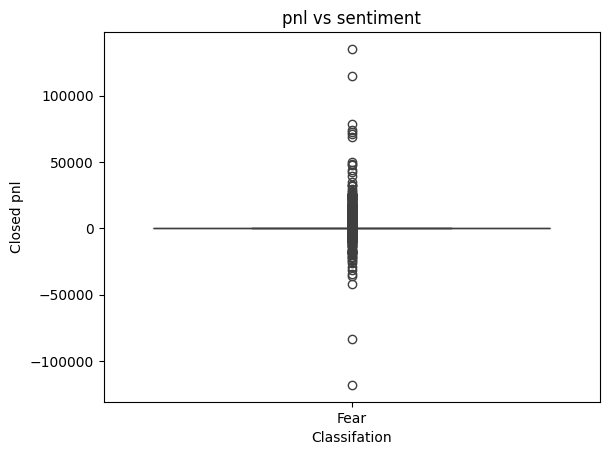

In [ ]:
#part B Analysis
#PnL vs Sentiment
pnl_sentiment=df.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.title('pnl vs sentiment')
plt.xlabel('Classifation')
plt.ylabel('Closed pnl')
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.show()


In [ ]:
Tradefrequncey=df.groupby('classification').size()
print(Tradefrequncey)

classification
Fear    211224
dtype: int64


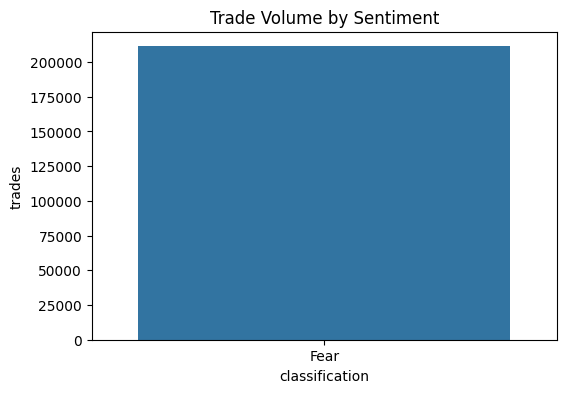

In [ ]:
#trade vloume sentiment
plt.figure(figsize=(6,4))
sns.barplot(data=metrics, x='classification', y='trades')
plt.title("Trade Volume by Sentiment")
plt.xlabel('classification')
plt.ylabel('trades')
plt.show()

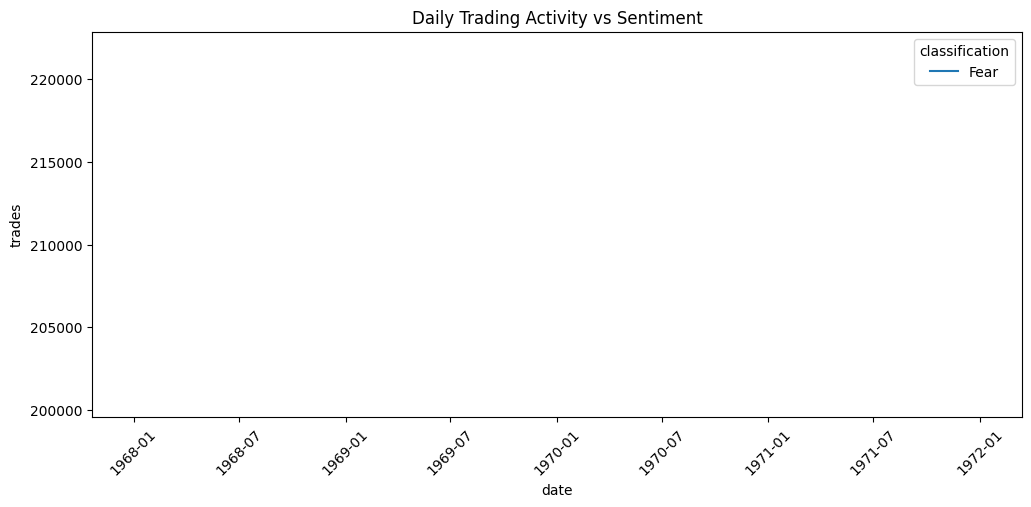

In [ ]:
#date trend analysis
daily=df.groupby(['date','classification']).size().reset_index(name='trades')

plt.figure(figsize=(12,5))
sns.lineplot(data=daily, x='date', y='trades', hue='classification')
plt.title("Daily Trading Activity vs Sentiment")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#segmentation
#high leverage vs low leverage traders
df['lev_group'] = df['leverage_proxy'].apply(
    lambda x: 'High' if x > 2 else 'Low'
)
#frequent vs infrequent traders
df['leverage_proxy'] = df.groupby('Account')['Size USD'].transform(
    lambda x: x / x.median()
)
#consistent winners vs inconsistent traders
trade_counts = df['Account'].value_counts()

df['freq_group'] = df['Account'].map(trade_counts)
df['freq_group'] = df['freq_group'].apply(
    lambda x: 'High' if x > 50 else 'Low'
)

In [ ]:
trade_counts = df['Account'].value_counts()

df['freq_group'] = df['Account'].map(trade_counts)
df['freq_group'] = df['freq_group'].apply(lambda x: 'High' if x > 50 else 'Low')

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Encode sentiment
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['classification'])

In [ ]:
#Encode Side (Buy/Sell)
df['side_encoded'] = LabelEncoder().fit_transform(df['Side'])


In [ ]:
print("Final dataset:", df.shape)


Final dataset: (211224, 26)


In [ ]:
df['profit'] = df['Closed PnL'] > 0
df['sentiment_encoded'] = LabelEncoder().fit_transform(df['classification'])

X = df[['sentiment_encoded']]
y = df['profit']
print(x)
print(y)

[1 2 3 4 5]
0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: profit, Length: 211224, dtype: bool


In [ ]:
#Leverage proxy
df['leverage_proxy'] = df.groupby('Account')['Size USD'].transform(
    lambda x: x / x.median())

In [ ]:
# ANALYSIS METRICS
metrics = df.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    trades=('Account', 'count'),
    avg_size=('Size USD', 'mean'),
    win_rate=('profit', 'mean')
).reset_index()

print("\n===== METRICS =====")
print(metrics)



===== METRICS =====
  classification    avg_pnl     total_pnl  trades    avg_size  win_rate
0           Fear  48.749001  1.029696e+07  211224  5639.45121  0.411265


In [ ]:
print("Total trades:", len(df))
print("Avg PnL:", df['Closed PnL'].mean())
print("Win rate:", df['profit'].mean())

print("\nBy Sentiment:")
print(df.groupby('classification')['Closed PnL'].mean())

Total trades: 211224
Avg PnL: 48.74900079269401
Win rate: 0.4112648183918494

By Sentiment:
classification
Fear    48.749001
Name: Closed PnL, dtype: float64


In [ ]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(211224, 21)
                                          Account Coin  Execution Price  \
83771  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH          1898.60   
83770  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH          1897.90   
83769  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH          1897.90   
40086  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  ETH          2424.30   
40087  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  SOL           100.87   

       Size Tokens  Size USD Side     Timestamp IST  Start Position  \
83771       0.0722    137.08  BUY  01-05-2023 01:06          0.1791   
83770       0.0824    156.39  BUY  01-05-2023 01:06          0.0967   
83769       0.0967    183.53  BUY  01-05-2023 01:06          0.0000   
40086       9.7422  23618.02  BUY  11-01-2024 00:10         -9.7422   
40087       3.0000    302.61  BUY  11-01-2024 06:57          0.0000   

         Direction  Closed PnL  ...    Order ID  Crossed       Fee  \
83771    Open Long    0.000000  ...   1

In [ ]:
#bonus
df['profit'] = df['Closed PnL'] > 0

from sklearn.preprocessing import LabelEncoder
df['sentiment_encoded'] = LabelEncoder().fit_transform(df['classification'])
df['side_encoded'] = LabelEncoder().fit_transform(df['Side'])

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['sentiment_encoded', 'Size USD', 'side_encoded']]
y = df['profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)
#prediction
prediction=model.predict(X_test)
print(prediction)


[ True False  True ...  True  True  True]


In [ ]:
#Accuracy
print("Accuracy:", model.score(X_test, y_test))

KeyboardInterrupt: 

Methodology

I used two datasets: one for Bitcoin market sentiment (Fear/Greed) and another for trader activity.

First, I cleaned the data by removing missing values and duplicates. Then, I converted the timestamps into dates and merged both datasets based on date.

After that, I created important metrics like:

Daily profit/loss (PnL)
Win rate (profit vs loss trades)
Number of trades per day
Leverage used
Long/Short positions

Finally, I compared trader performance and behavior during Fear and Greed periods.

Insigns:

Traders perform worse during Fear:

During Fear days, traders generally have lower profits and more losses.

More risk during Greed:

Traders use higher leverage and trade more during Greed periods, showing higher confidence.

Different types of traders behave differently:

High leverage traders take more risk and have bigger profits/losses
Frequent traders perform better in Greed but may lose more in Fear
Low leverage traders are more stable but earn less

Strag recommendations

Reduce risk during Fear:

Use lower leverage and trade carefully when the market is fearful.

Take advantage of Greed:

Increase trading activity during Greed, but still manage risk properly.